In [1]:
import sys
import os
import torch
sys.path.insert(0, r"d:\VS codes\ML Coding")

import configs.config as cfg
from utils.split           import (get_existing_image_ids,
                                    split_image_ids,
                                    save_split, load_split)
from dataset.split_dataset import (SplitCOCODataset,
                                    build_split_dataloaders)
from dataset.transforms    import (get_train_transforms,
                                    get_val_transforms)
from torch.utils.data      import DataLoader
from dataset.coco_dataset  import collate_fn

device = torch.device(cfg.DEVICE)
print(f"Device  : {device}")
print(f"Imports : OK")

Device  : cpu
Imports : OK


In [2]:
SPLIT_FILE = r"d:\VS codes\ML Coding\data_split.json"

if not os.path.exists(SPLIT_FILE):
    print("Creating new split...\n")

    # Find all images that actually exist
    image_ids = get_existing_image_ids(
        cfg.TRAIN_ANN,
        cfg.TRAIN_IMG_DIR,
    )

    # Split 80/20
    train_ids, val_ids = split_image_ids(
        image_ids,
        val_ratio = 0.2,
        seed      = 42,
    )

    # Save for reproducibility
    save_split(train_ids, val_ids, SPLIT_FILE)
else:
    print("Loading existing split...\n")
    train_ids, val_ids = load_split(SPLIT_FILE)

print(f"\nSplit summary:")
print(f"  Train : {len(train_ids)} images")
print(f"  Val   : {len(val_ids)} images")
print(f"  Total : {len(train_ids)+len(val_ids)} images")
print(f"  Ratio : {len(val_ids)/(len(train_ids)+len(val_ids)):.1%} val")

Creating new split...

loading annotations into memory...
Done (t=16.94s)
creating index...
index created!
[Split] Total images in annotation : 118287
[Split] Images found in folder     : 70081
[Split] Train images : 56065
[Split] Val images   : 14016
[Split] Val ratio    : 20.0%
[Split] Saved → d:\VS codes\ML Coding\data_split.json

Split summary:
  Train : 56065 images
  Val   : 14016 images
  Total : 70081 images
  Ratio : 20.0% val


In [3]:
train_loader, val_loader = build_split_dataloaders(
    cfg, SPLIT_FILE
)

# Verify one batch from each
train_imgs, train_tgts = next(iter(train_loader))
val_imgs,   val_tgts   = next(iter(val_loader))

print("=== DataLoader Verification ===\n")
print(f"Train batch:")
print(f"  Images  : {len(train_imgs)}")
print(f"  Img 0 shape : {train_imgs[0].shape}")
print(f"  Boxes 0 : {train_tgts[0]['boxes'].shape}")
print(f"  Labels 0: {train_tgts[0]['labels'].tolist()}")

print(f"\nVal batch:")
print(f"  Images  : {len(val_imgs)}")
print(f"  Img 0 shape : {val_imgs[0].shape}")
print(f"  Boxes 0 : {val_tgts[0]['boxes'].shape}")

[Split] Loaded — train=56065, val=14016
loading annotations into memory...
Done (t=17.18s)
creating index...
index created!
  SplitDataset: 56065 images with target classes
loading annotations into memory...
Done (t=15.53s)
creating index...
index created!
  SplitDataset: 14016 images with target classes

  Train: 56065 images → 14016 batches
  Val  : 14016 images → 14016 batches



d:\VS codes\ML Coding\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== DataLoader Verification ===

Train batch:
  Images  : 4
  Img 0 shape : torch.Size([3, 427, 640])
  Boxes 0 : torch.Size([1, 4])
  Labels 0: [1]

Val batch:
  Images  : 1
  Img 0 shape : torch.Size([3, 640, 428])
  Boxes 0 : torch.Size([8, 4])


In [4]:
from model.detector      import build_detector
from training.trainer    import train_one_epoch
from training.evaluator  import evaluate_one_epoch
from torch.amp           import GradScaler
from torch.utils.data    import Subset

# Build model
model = build_detector(
    cfg.NUM_CLASSES,
    pretrained_backbone = True
).to(device)

# Small subsets for speed
from dataset.split_dataset import SplitCOCODataset
from dataset.transforms    import get_train_transforms, get_val_transforms

small_train_ds = SplitCOCODataset(
    cfg.TRAIN_IMG_DIR, cfg.TRAIN_ANN,
    train_ids[:20],
    transforms = get_train_transforms()
)
small_val_ds = SplitCOCODataset(
    cfg.TRAIN_IMG_DIR, cfg.TRAIN_ANN,
    val_ids[:10],
    transforms = get_val_transforms()
)

small_train = DataLoader(
    small_train_ds, batch_size=2,
    shuffle=True, collate_fn=collate_fn,
    num_workers=0
)
small_val = DataLoader(
    small_val_ds, batch_size=1,
    shuffle=False, collate_fn=collate_fn,
    num_workers=0
)

# Build optimizer + scaler
params    = [p for p in model.parameters()
             if p.requires_grad]
optimizer = torch.optim.SGD(
    params, lr=cfg.LR,
    momentum=cfg.MOMENTUM,
    weight_decay=cfg.WEIGHT_DECAY
)
scaler = GradScaler("cuda",
           enabled=(device.type == "cuda"))

print("=== Mini Full Pipeline Run ===\n")
print("Training 1 epoch on 20 images...")

# Train
train_losses = train_one_epoch(
    model=model, optimizer=optimizer,
    data_loader=small_train,
    device=device, epoch=1,
    scaler=scaler, print_freq=5,
)

print("\nEvaluating on 10 images...")

# Evaluate
val_metrics = evaluate_one_epoch(
    model=model, data_loader=small_val,
    device=device, epoch=1,
    score_thresh=0.05,
)

print(f"\n  Train loss : "
      f"{sum(train_losses.values()):.4f}")
print(f"  Val mAP    : {val_metrics['mAP']:.4f}")
print(f"\nFull pipeline run complete!")

[Backbone] Built resnet50 + FPN
[Backbone] Output channels: 256
[Backbone] Pretrained: True
[Backbone] Frozen params: 24 | Trainable params: 45

[Detector] Model built successfully
[Detector] Backbone    : resnet50 + FPN
[Detector] Num classes : 7 (including background)
[Detector] Anchors     : 5 levels x 3 ratios = 15 anchor types
[Detector] ROI output  : 7x7 per proposal

loading annotations into memory...
Done (t=19.27s)
creating index...
index created!
  SplitDataset: 20 images with target classes
loading annotations into memory...
Done (t=21.26s)
creating index...
index created!
  SplitDataset: 10 images with target classes
=== Mini Full Pipeline Run ===

Training 1 epoch on 20 images...


d:\VS codes\ML Coding\training\trainer.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


  Epoch [  1] Batch [   1/10] Loss: 3.0562 Avg: 3.0562 LR: 0.005000 Time: 28.8s
  Epoch [  1] Batch [   5/10] Loss: 1.5193 Avg: 2.3038 LR: 0.005000 Time: 107.1s
  Epoch [  1] Batch [  10/10] Loss: 1.2658 Avg: 1.8391 LR: 0.005000 Time: 227.9s

  Epoch 1 — Loss Summary
  ────────────────────────────────────────
  loss_classifier           1.0080  ██████████
  loss_box_reg              0.0358  
  loss_objectness           0.6984  ███████
  loss_rpn_box_reg          0.0969  █
  ────────────────────────────────────────
  Total                     1.8391
  Epoch 1 completed in 228.3s

Evaluating on 10 images...

  [Eval] Running evaluation on 10 images...
  [Eval] Forward passes done in 42.0s
  [Eval] Computing mAP...

  mAP@0.50 = 0.0010

  Class                 AP
  -------------------------
  person            0.0059  
  bicycle           0.0000  
  car               0.0000  
  motorcycle        0.0000  
  bus               0.0000  
  truck             0.0000  
  [Eval] Total time: 42.7s


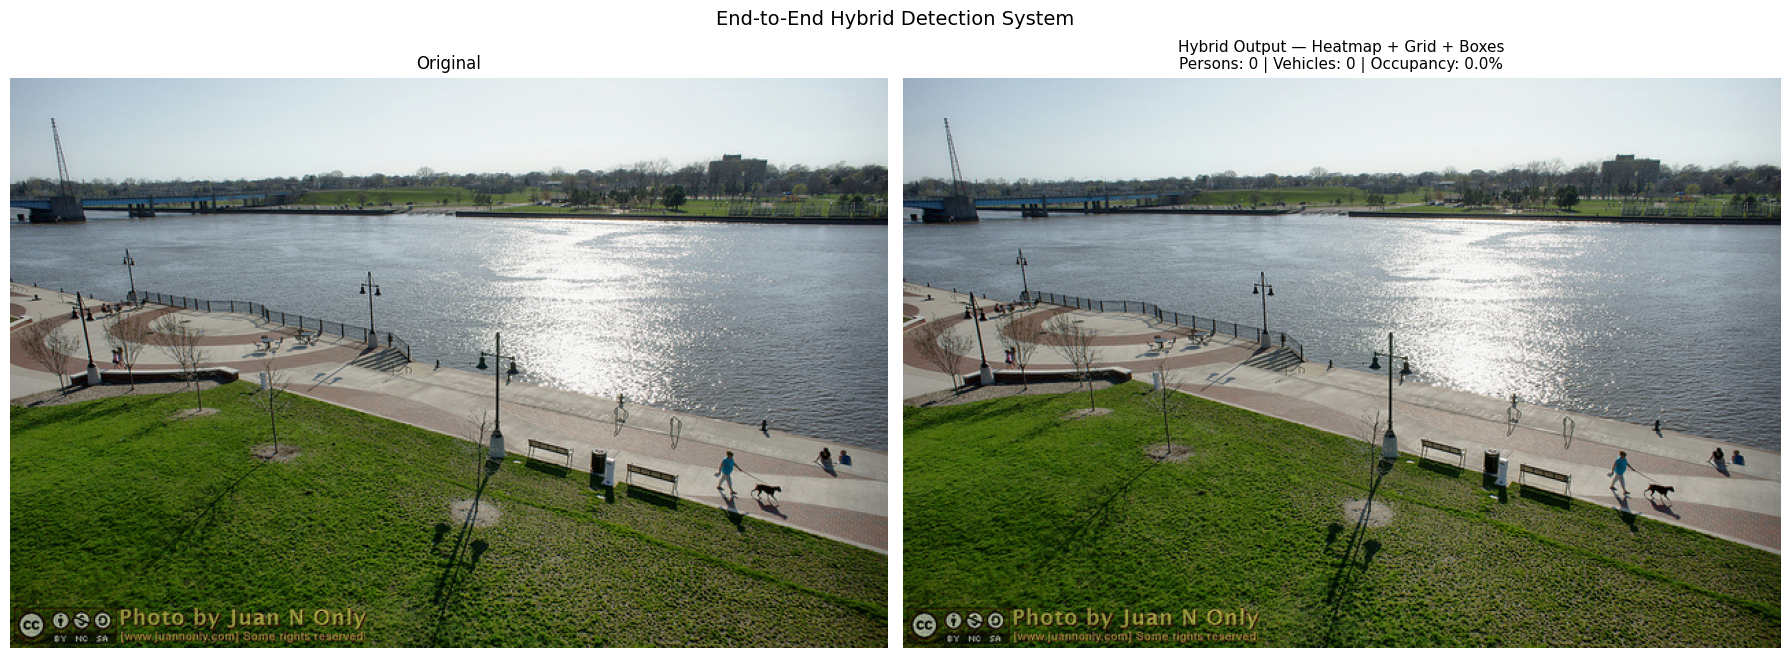

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import importlib.util

# Load inference module
spec = importlib.util.spec_from_file_location(
    "inference",
    r"d:\VS codes\ML Coding\inference.py"
)
inf_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(inf_mod)

from utils.density import (
    detections_from_model_output,
    build_hybrid_frame,
)

# Get one image
img_path = os.path.join(
    cfg.TRAIN_IMG_DIR,
    os.listdir(cfg.TRAIN_IMG_DIR)[10]
)

# Preprocess + infer
tensor, orig_size = inf_mod.preprocess_image(img_path)
tensor = tensor.to(device)

model.eval()
with torch.no_grad():
    raw_out = model([tensor])

# Postprocess
dets_dict = inf_mod.postprocess_detections(
    raw_out[0], orig_size,
    score_thresh = 0.3,
)

# Convert to DetectionResult objects
det_results = detections_from_model_output(dets_dict)

# Build hybrid frame
frame  = cv2.imread(img_path)
hybrid, grid_r, density = build_hybrid_frame(
    frame      = frame,
    detections = det_results,
    show_heatmap  = True,
    show_grid     = True,
    show_boxes    = True,
    sigma         = 20.0,
    cell_size     = 64,
    heatmap_alpha = 0.45,
    grid_alpha    = 0.25,
)

# Display
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original", fontsize=12)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(hybrid, cv2.COLOR_BGR2RGB))
axes[1].set_title(
    f"Hybrid Output — Heatmap + Grid + Boxes\n"
    f"Persons: "
    f"{sum(1 for d in det_results if d.class_name=='person')} | "
    f"Vehicles: "
    f"{sum(1 for d in det_results if d.class_name in ('car','truck','bus'))} | "
    f"Occupancy: {grid_r.occupancy:.1%}",
    fontsize=11
)
axes[1].axis("off")

plt.suptitle("End-to-End Hybrid Detection System",
             fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
import os

checks = {}

# 1. Split file exists
checks["Train/val split created"] = (
    os.path.exists(SPLIT_FILE)
)

# 2. DataLoaders work
checks["Train DataLoader works"]  = (
    len(train_loader) > 0
)
checks["Val DataLoader works"]    = (
    len(val_loader) > 0
)

# 3. Model components
checks["Model builds correctly"]  = model is not None
checks["Model has 7 classes"]     = (
    model.roi_heads.box_predictor
    .cls_score.out_features == 7
)

# 4. Checkpoint dir exists
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
checks["Checkpoint dir ready"]    = (
    os.path.exists(cfg.CHECKPOINT_DIR)
)

# 5. Config complete
required_attrs = [
    "DEVICE", "NUM_CLASSES", "BACKBONE",
    "BATCH_SIZE", "NUM_EPOCHS", "LR",
    "TRAIN_IMG_DIR", "TRAIN_ANN",
    "CHECKPOINT_DIR", "SCORE_THRESHOLD",
    "CROWD_DENSITY_HIGH", "CROWD_DENSITY_MED",
]
checks["Config has all fields"]   = all(
    hasattr(cfg, attr) for attr in required_attrs
)

# 6. Images exist
img_count = len(os.listdir(cfg.TRAIN_IMG_DIR))
checks[f"Images found ({img_count})"] = img_count > 0

# 7. Full pipeline ran
checks["Full pipeline test passed"] = (
    val_metrics is not None
)

print("=== Step 10 Checklist ===\n")
all_passed = True
for check, passed in checks.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {check}")
    if not passed:
        all_passed = False

print()
if all_passed:
    print("🎉 ALL STEPS COMPLETE!")
    print("   System is ready for training on GPU!")
else:
    print("Fix failing checks before training.")

=== Step 10 Checklist ===

  ✅  Train/val split created
  ✅  Train DataLoader works
  ✅  Val DataLoader works
  ✅  Model builds correctly
  ✅  Model has 7 classes
  ✅  Checkpoint dir ready
  ✅  Config has all fields
  ✅  Images found (70081)
  ✅  Full pipeline test passed

🎉 ALL STEPS COMPLETE!
   System is ready for training on GPU!


In [9]:
print("""
╔══════════════════════════════════════════════════════╗
║         GPU TRAINING GUIDE                           ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. COPY PROJECT TO FRIEND'S MACHINE                 ║
║     Copy entire folder:                              ║
║     d:\\VS codes\\ML Coding\\                        ║
║     (excluding venv folder)                          ║
║                                                      ║
║  2. VERIFY GPU                                       ║
║     nvidia-smi                                       ║
║                                                      ║
║  3. SETUP ENVIRONMENT                                ║
║     python -m venv venv                              ║
║     venv\\Scripts\\activate                          ║
║                                                      ║
║  4. INSTALL PYTORCH WITH CUDA                        ║
║     Check CUDA version first: nvidia-smi             ║
║     CUDA 12.1:                                       ║
║     pip install torch torchvision                    ║
║         --index-url                                  ║
║         https://download.pytorch.org/whl/cu121       ║
║                                                      ║
║  5. INSTALL OTHER DEPS                               ║
║     pip install -r requirements.txt                  ║
║                                                      ║
║  6. UPDATE CONFIG PATH                               ║
║     Edit configs/config.py                           ║
║     Change TRAIN_IMG_DIR and TRAIN_ANN               ║
║     to match friend's machine paths                  ║
║                                                      ║
║  7. START TRAINING                                   ║
║     python train.py                                  ║
║                                                      ║
║  8. MONITOR TRAINING                                 ║
║     tensorboard --logdir logs/                       ║
║     Open browser: http://localhost:6006              ║
║                                                      ║
║  9. RUN INFERENCE AFTER TRAINING                     ║
║     python inference.py                              ║
║         --source test_image.jpg                      ║
║         --checkpoint checkpoints/best_model.pth      ║
║                                                      ║
╠══════════════════════════════════════════════════════╣
║  EXPECTED TRAINING TIME (rough estimates)            ║
║  RTX 3060 : ~4-6 hours for 20 epochs                 ║
║  RTX 3080 : ~2-3 hours for 20 epochs                 ║
║  RTX 4090 : ~1-2 hours for 20 epochs                 ║
╠══════════════════════════════════════════════════════╣
║  EXPECTED FINAL mAP (on your dataset size)           ║
║  < 5,000 images  : mAP ~0.20-0.30                    ║
║  5k-20k images   : mAP ~0.30-0.45                    ║
║  > 20k images    : mAP ~0.45-0.60                    ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║         GPU TRAINING GUIDE                           ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. COPY PROJECT TO FRIEND'S MACHINE                 ║
║     Copy entire folder:                              ║
║     d:\VS codes\ML Coding\                        ║
║     (excluding venv folder)                          ║
║                                                      ║
║  2. VERIFY GPU                                       ║
║     nvidia-smi                                       ║
║                                                      ║
║  3. SETUP ENVIRONMENT                                ║
║     python -m venv venv                              ║
║     venv\Scripts\activate                          ║
║                                                      ║
║  4. INSTALL PYTORCH WITH CUDA                        ║
║     Check CUDA version first: nvi

In [10]:
print("""
odm_model/
├── configs/
│   └── config.py              ✅ all hyperparameters
│
├── model/
│   ├── backbone.py            ✅ ResNet50 + FPN
│   ├── detector.py            ✅ Faster-RCNN
│   └── __init__.py
│
├── dataset/
│   ├── coco_dataset.py        ✅ COCO loader
│   ├── split_dataset.py       ✅ train/val split
│   ├── transforms.py          ✅ augmentation
│   └── __init__.py
│
├── losses/
│   ├── detection_loss.py      ✅ loss computation
│   └── __init__.py
│
├── utils/
│   ├── iou.py                 ✅ IoU computation
│   ├── nms.py                 ✅ NMS
│   ├── box_utils.py           ✅ format conversion
│   ├── metrics.py             ✅ mAP computation
│   ├── visualization.py       ✅ drawing utilities
│   ├── density.py             ✅ heatmap + grid
│   ├── split.py               ✅ data splitting
│   └── __init__.py
│
├── training/
│   ├── trainer.py             ✅ training loop
│   ├── evaluator.py           ✅ mAP evaluation
│   ├── scheduler.py           ✅ LR scheduling
│   └── __init__.py
│
├── People_vehicles dataset/   ✅ your COCO data
├── checkpoints/               ✅ saved models
├── data_split.json            ✅ reproducible split
├── train.py                   ✅ main training script
├── inference.py               ✅ inference pipeline
├── configs/config.py          ✅ all settings
└── requirements.txt           ✅ dependencies
""")


odm_model/
├── configs/
│   └── config.py              ✅ all hyperparameters
│
├── model/
│   ├── backbone.py            ✅ ResNet50 + FPN
│   ├── detector.py            ✅ Faster-RCNN
│   └── __init__.py
│
├── dataset/
│   ├── coco_dataset.py        ✅ COCO loader
│   ├── split_dataset.py       ✅ train/val split
│   ├── transforms.py          ✅ augmentation
│   └── __init__.py
│
├── losses/
│   ├── detection_loss.py      ✅ loss computation
│   └── __init__.py
│
├── utils/
│   ├── iou.py                 ✅ IoU computation
│   ├── nms.py                 ✅ NMS
│   ├── box_utils.py           ✅ format conversion
│   ├── metrics.py             ✅ mAP computation
│   ├── visualization.py       ✅ drawing utilities
│   ├── density.py             ✅ heatmap + grid
│   ├── split.py               ✅ data splitting
│   └── __init__.py
│
├── training/
│   ├── trainer.py             ✅ training loop
│   ├── evaluator.py           ✅ mAP evaluation
│   ├── scheduler.py           ✅ LR scheduling
│   └── __ini